In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'HR_capstone_dataset.csv')

In [3]:
df.shape

(14999, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


# No Need to Clean Data as it is already cleaned just have to perform analysis 

# KPI's 

In [5]:
df=df.drop_duplicates()

In [6]:
# --- Total Employees ---

df['satisfaction_level'].count()   # 14999

np.int64(11991)

In [7]:
# AVG Monthly Hours
df['average_montly_hours'].median()

np.float64(200.0)

In [8]:
# Employee Retention Rate 
(df['left'].sum())/(df['satisfaction_level'].count())*100  # 16 Percent 

np.float64(16.604119756484028)

In [10]:
# Total Departments
len(df['Department'].unique())

10

# Overview Tab

# Analysis 

# Employees By Department

<Axes: title={'center': 'Employees By Department'}, ylabel='count'>

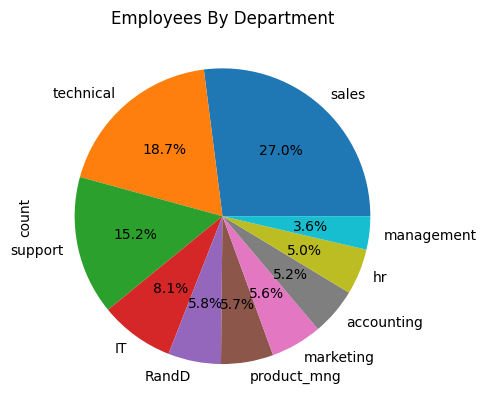

In [11]:
df['Department'].value_counts().plot(kind='pie',title='Employees By Department',autopct='%1.1f%%')

# Time Spent At Company

<Axes: title={'center': 'Time Spent At Company By Employees'}, xlabel='Years', ylabel='Employees'>

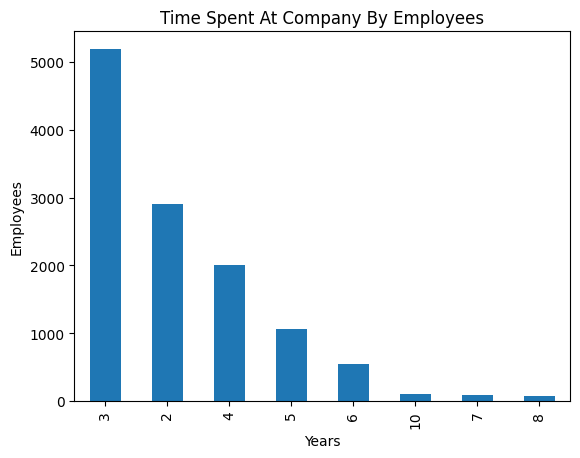

In [12]:
df['time_spend_company'].value_counts().plot(kind='bar',title='Time Spent At Company By Employees',ylabel='Employees',xlabel='Years')

# Employees By Department and AVG Working Hours

In [13]:
department  = df['Department']
avg_working_Hours = df['average_montly_hours']

In [14]:
chart1 = df.groupby('Department').agg({'average_montly_hours':'median'})

<Axes: xlabel='Department'>

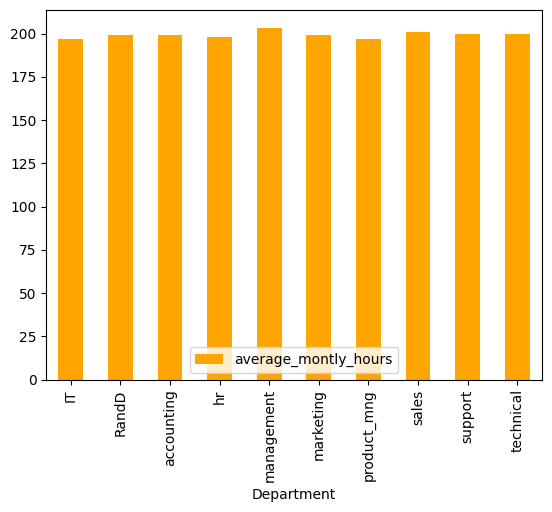

In [15]:
chart1.plot(kind='bar',color='orange')

# Correlation

In [16]:
correlation = df.corr(numeric_only=True)

<Axes: >

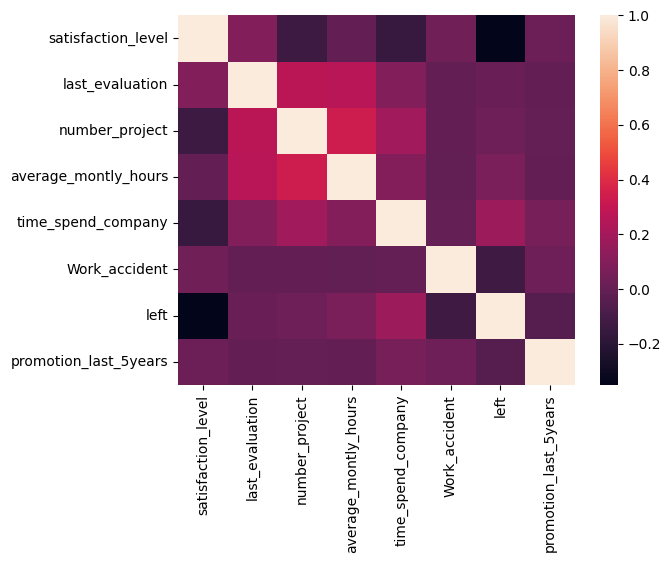

In [17]:
sns.heatmap(correlation)

# Details Tab

In [19]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Number of Project Completed by Department along with Work Accident

<Axes: title={'center': 'No of Projects vs Work Accident'}, xlabel='Department'>

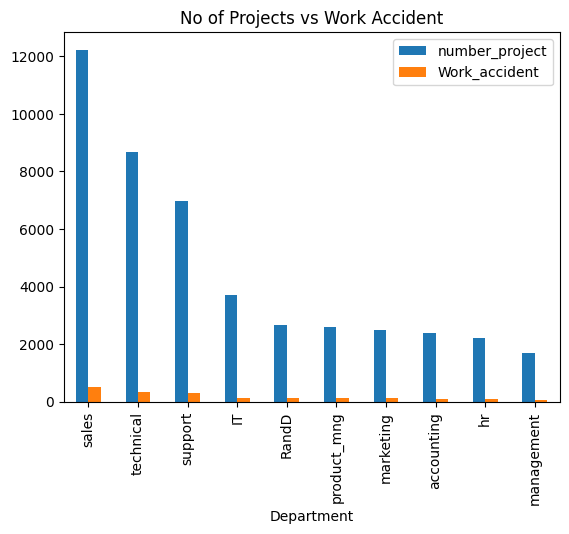

In [20]:
df.groupby('Department').agg({'number_project':'sum','Work_accident':'sum'}).sort_values(by='number_project',ascending=False).plot(kind='bar',title='No of Projects vs Work Accident')

# Salary By Department

array([<Axes: xlabel='salary'>], dtype=object)

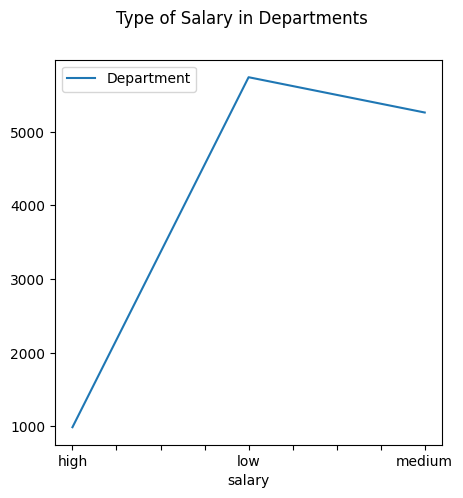

In [21]:
df.groupby('salary').agg({'Department':'count'}).plot(kind='line',subplots=True,figsize=(5,5),title='Type of Salary in Departments')

# Time Spend and Left By Department and Salary

<Axes: xlabel='Department,salary'>

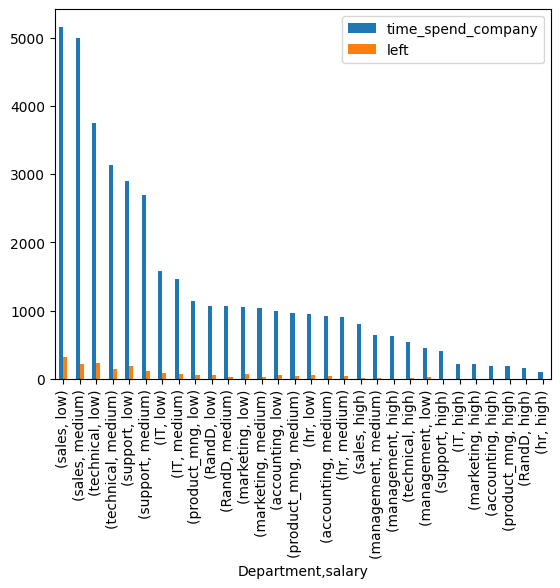

In [22]:
df.groupby(['Department','salary']).agg({'time_spend_company':'sum','left':'sum'}).sort_values(by='time_spend_company',ascending=False).plot(kind='bar')

In [23]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [24]:
df['promotion_last_5years'].value_counts()

promotion_last_5years
0    11788
1      203
Name: count, dtype: int64

<Axes: xlabel='promotion_last_5years'>

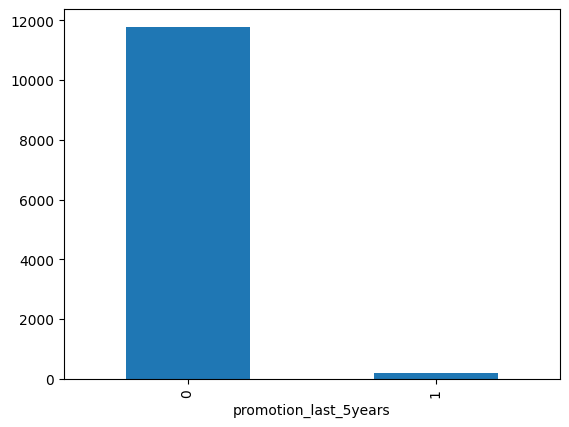

In [25]:
df['promotion_last_5years'].value_counts().plot(kind='bar')